###**Introduction**:
Credit card fraud has become one of the major challenges in the financial industry due to the rapid growth of digital transactions and online payment systems. Detecting fraudulent transactions accurately is essential to reduce financial losses and improve transaction security.

This project focuses on building a Machine Learning-based Credit Card Fraud Detection System using classification algorithms such as Logistic Regression, Decision Tree, and Random Forest. The project involves data preprocessing, duplicate removal, feature scaling, exploratory data analysis, and model evaluation using confusion matrices and ROC curves.

The goal of this project is to analyze transaction patterns and develop predictive models capable of identifying fraudulent transactions effectively.

###**Objective**:
The main objective of this project is to build an efficient Machine Learning model for detecting fraudulent credit card transactions.

The specific objectives are:

• Perform data preprocessing and cleaning techniques on transaction data

• Handle duplicate records and prepare the dataset for model training

• Analyze fraud and non-fraud transaction patterns using visualizations

• Train and evaluate multiple Machine Learning classification algorithms

• Compare model performance using accuracy, confusion matrix, classification report, and ROC curve

• Identify the best-performing model for fraud detection

**Import Required Libraries**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

**Load and understanding the Dataset**

In [7]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print("Shape of dataset:", df.shape)

Shape of dataset: (284807, 31)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

###**Data Cleaning and Preprocessing**
**Check Missing Values & Duplicates**

In [10]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [11]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 1081


In [12]:
df = df.dropna()
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [13]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


###**Exploratory Data Analysis (EDA)**
**Check Fraud vs Non-Fraud Distribution**

In [14]:
print(df['Class'].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


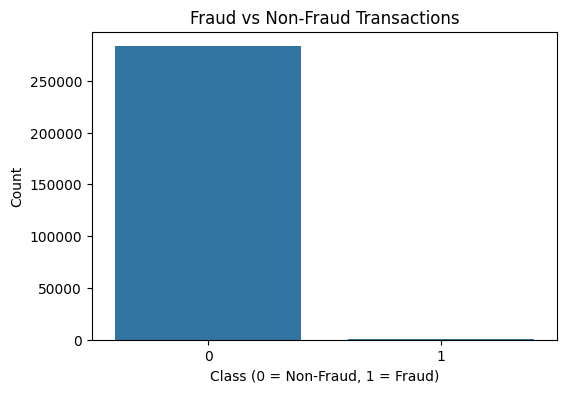

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

**Fraud Percentage Pie Chart**

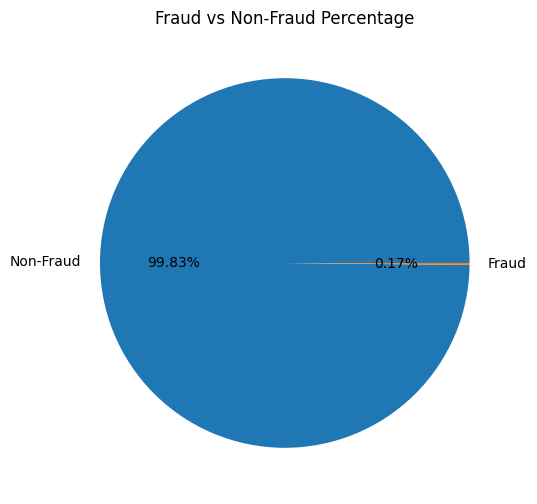

In [16]:
fraud_counts = df['Class'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    fraud_counts,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.2f%%'
)
plt.title("Fraud vs Non-Fraud Percentage")
plt.show()

**Transaction Amount Distribution**

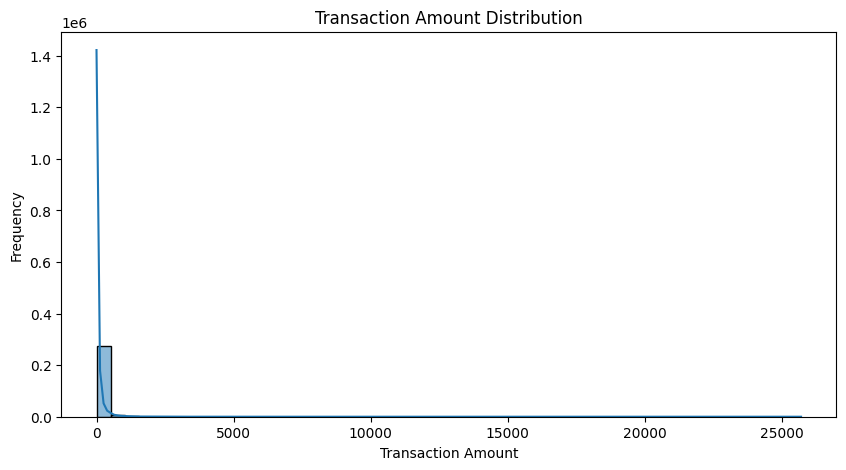

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

**Fraud vs Non-Fraud Transaction Amounts**

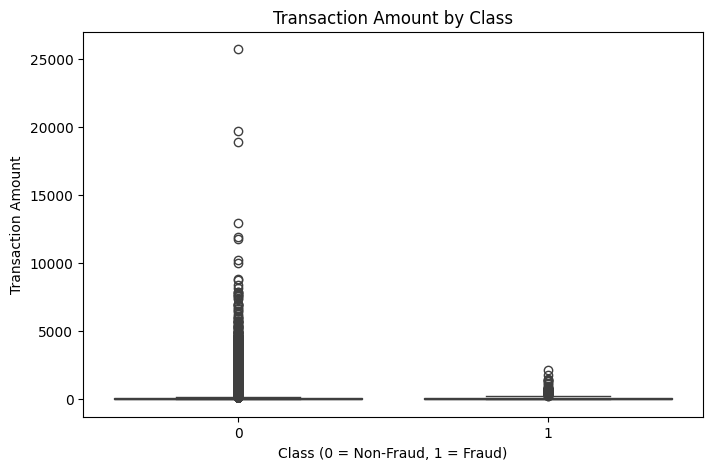

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

**Correlation Heatmap**

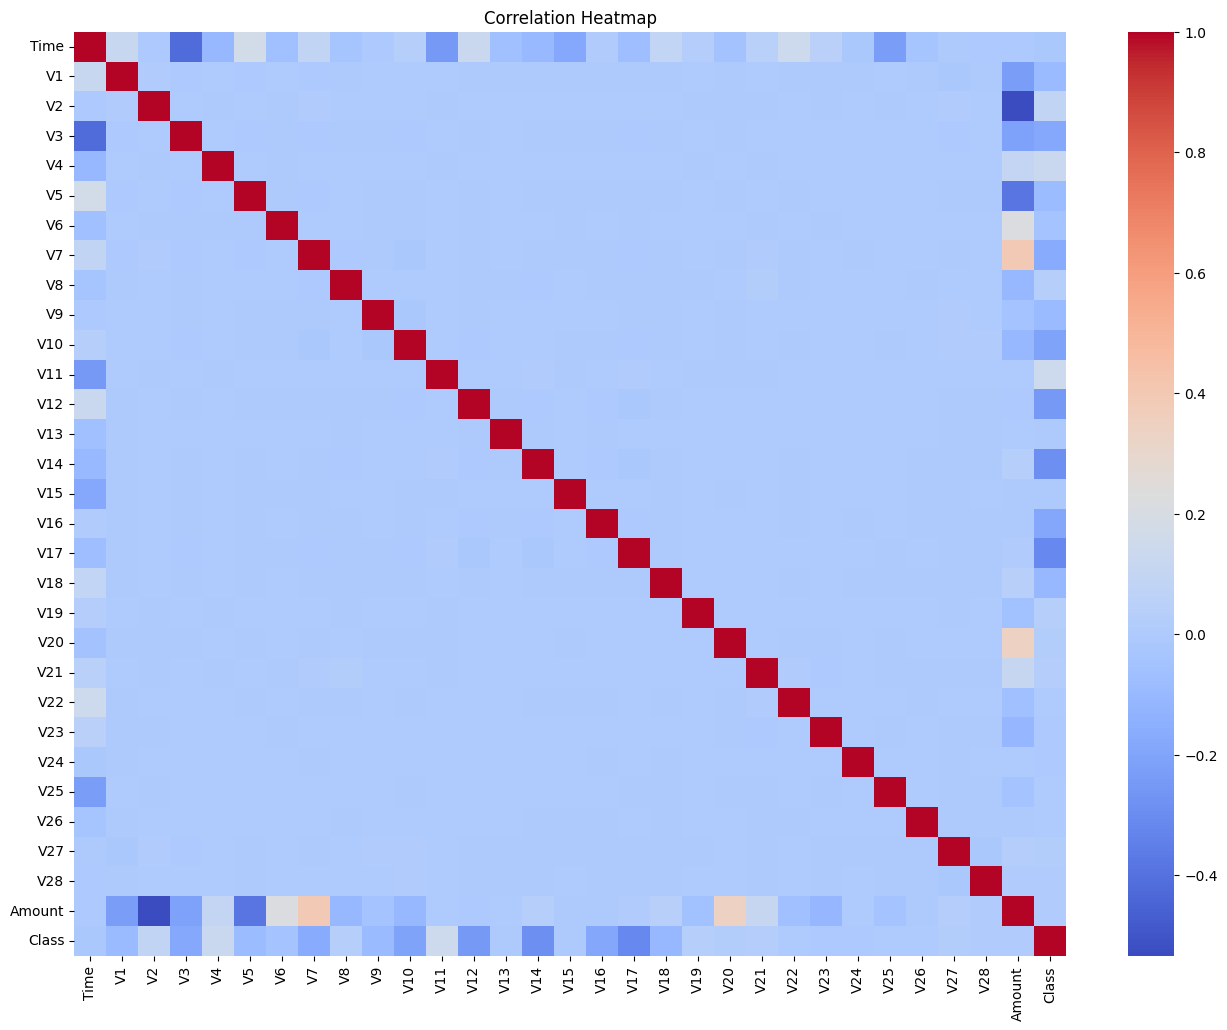

In [19]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

###**Feature Scaling**

In [20]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


In [21]:
X = df.drop('Class', axis=1)
y = df['Class']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (283726, 30)
Target Shape: (283726,)


### **Train-Test Split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (226980, 30)
Testing Data Shape: (56746, 30)


## **Machine Learning Model**

### **Logistic Regression Model**

In [23]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9991717477883904


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.61      0.71        95

    accuracy                           1.00     56746
   macro avg       0.93      0.81      0.86     56746
weighted avg       1.00      1.00      1.00     56746



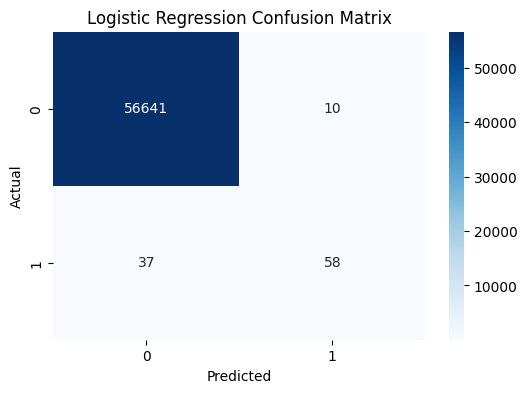

In [25]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve for Logistic Regression**

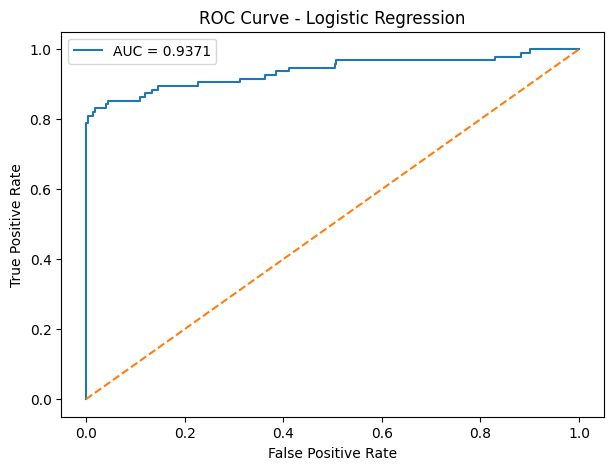

In [26]:
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = roc_auc_score(y_test, y_prob_lr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

###**Decision Tree Classifier**

In [27]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.999048391076023


In [28]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746



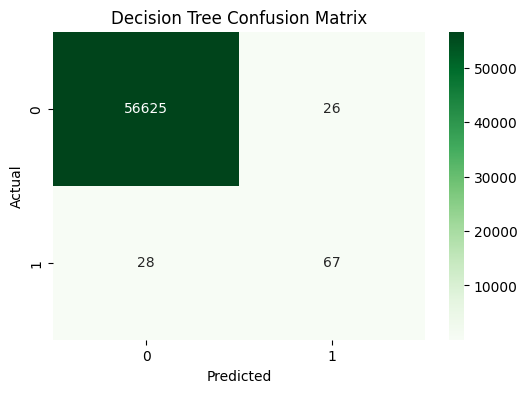

In [29]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve for Decision Tree**

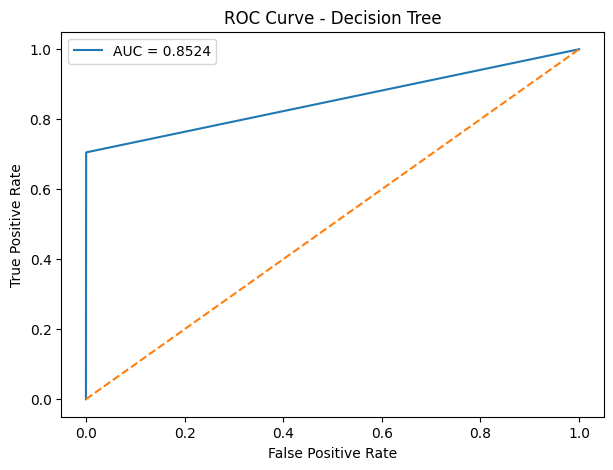

In [30]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.figure(figsize=(7,5))
plt.plot(fpr_dt, tpr_dt, label=f'AUC = {roc_auc_dt:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

###**Random Forest Classifier**

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9995065731505305


In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



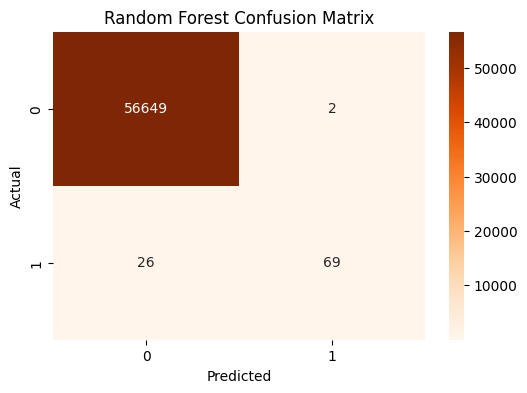

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve for Random Forest**

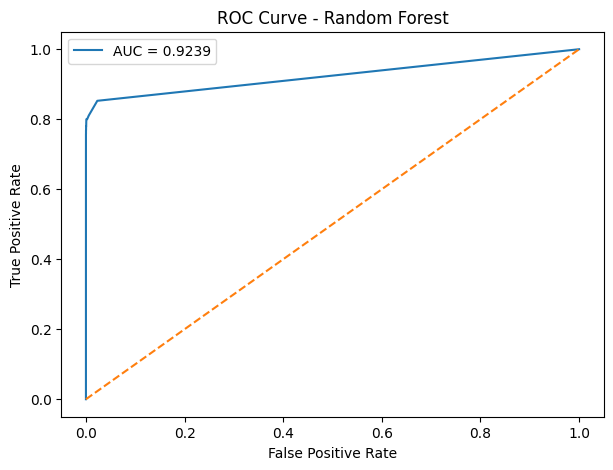

In [34]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_auc_rf:.4f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

###**Model Evaluation & Comparison**
**Model Comparison Table**

In [35]:
models = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})
models

,Model,Accuracy
0,Logistic Regression,0.999172
1,Decision Tree,0.999048
2,Random Forest,0.999507


**Visualization of Model Accuracy**

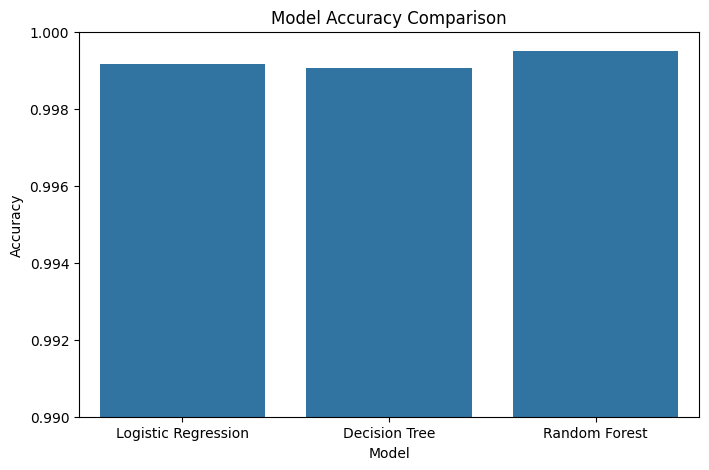

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=models
)
plt.title("Model Accuracy Comparison")
plt.ylim(0.99, 1.00)
plt.show()

**ROC Curve Comparison**

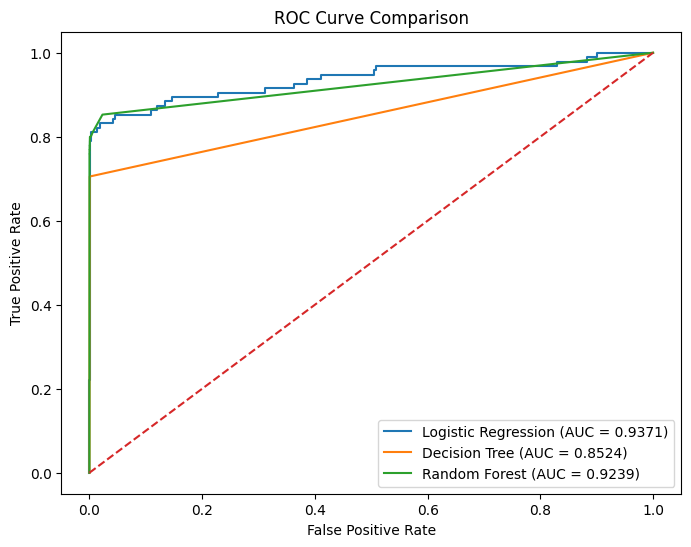

In [37]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

   Feature  Importance
17     V17    0.156591
14     V14    0.135281
12     V12    0.130206
10     V10    0.087799
16     V16    0.072675
11     V11    0.050980
9       V9    0.033680
18     V18    0.031980
4       V4    0.025802
7       V7    0.024569


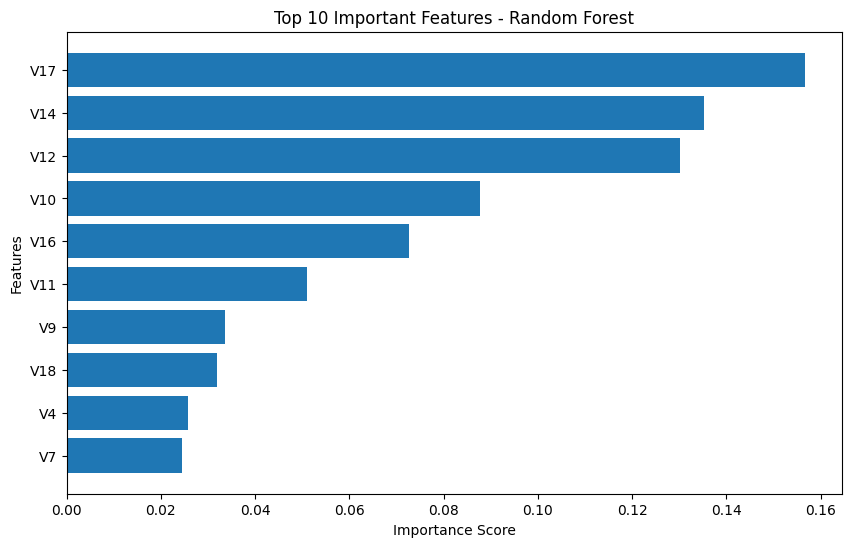

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
importance = rf_model.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
top_features = feature_importance.head(10)
print(top_features)
plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

###**Key Insights**:
• The dataset was highly imbalanced, with fraudulent transactions representing only a very small percentage of the total transactions.

• Data preprocessing techniques such as duplicate removal and feature scaling improved the quality and consistency of the dataset.

• Exploratory Data Analysis showed clear differences between fraud and non-fraud transaction distributions.

• Logistic Regression achieved high overall accuracy but showed lower recall in detecting fraudulent transactions.

• Decision Tree performed better in identifying fraud cases and provided improved recall and F1-score compared to Logistic Regression.

• Random Forest achieved the best overall performance among all models, with the highest accuracy and ROC-AUC score.

• ROC Curve analysis demonstrated that ensemble-based models like Random Forest are more effective for fraud detection tasks involving imbalanced datasets.

• The project highlighted the importance of Machine Learning techniques in identifying suspicious financial transactions and reducing fraud risks.

###**Conclusion**:
This project successfully developed a Machine Learning-based Credit Card Fraud Detection System using classification algorithms such as Logistic Regression, Decision Tree, and Random Forest.

The dataset was preprocessed by handling missing values, removing duplicate records, and scaling numerical features to improve model performance. Multiple visualizations and exploratory analyses were performed to understand transaction behavior and fraud distribution.

Among all models, the Random Forest Classifier delivered the best performance in detecting fraudulent transactions with high accuracy and strong ROC-AUC performance. The project demonstrated how Machine Learning can be effectively applied to financial fraud detection and risk analysis.

Overall, this project provided practical experience in data preprocessing, exploratory data analysis, supervised Machine Learning, model evaluation, and performance visualization using Python libraries such as Pandas, Matplotlib, Seaborn, and Scikit-learn.